# 03 — Approval Ratings DiD Analysis

Does losing US foreign aid shift how countries view US and Chinese leadership?

**Design:** Difference-in-Differences
- **Treatment:** High-aid countries (top 25% of 2024 aid/GDP ratio)
- **Pre/Post:** 2006–2024 (pre) vs. 2025 (post-USAID cuts)
- **Outcomes:** Gallup approval of US leadership, Gallup approval of Chinese leadership, and net approval (approve − disapprove) for each

## Helper Functions

| Function | Signature | What it does |
|---|---|---|
| `load_gallup` | `load_gallup(path, suffix)` | Loads a raw Gallup approval CSV (messy multi-header export), filters to country-level aggregates, parses "X%" strings to floats (0.X), and returns a tidy DataFrame with columns `country`, `year`, `approve_{suffix}`, `disapprove_{suffix}`, `net_{suffix}`. |

In [69]:
import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
import gdown
from scipy import stats

os.makedirs('../output', exist_ok=True)

## 1. Load Aid Data & Classify Treatment

In [70]:
# Load df_clean and prepare aid data
df_aid_raw = pd.read_csv('df_clean.csv', usecols=['ms_name', 'year', 'aid_gdp_ratio'])
df_aid_raw['country'] = df_aid_raw['ms_name'].str.strip().str.upper()

# Aggregate to one aid_gdp_ratio per country-year
# (df_clean has one row per UN resolution; aid ratio is constant within country-year)
df_aid = (
    df_aid_raw.groupby(['country', 'year'])['aid_gdp_ratio']
    .mean()
    .reset_index()
)

# Treatment classifier: top 25% by 2024 aid/GDP ratio
aid_2024 = (
    df_aid[df_aid['year'] == 2024][['country', 'aid_gdp_ratio']]
    .rename(columns={'aid_gdp_ratio': 'avg_aid_gdp'})
    .copy()
)
aid_2024['avg_aid_gdp'] = aid_2024['avg_aid_gdp'].fillna(0)
threshold = aid_2024['avg_aid_gdp'].quantile(0.75)
aid_2024['treated'] = (aid_2024['avg_aid_gdp'] >= threshold).astype(int)

print(f"Aid data: {df_aid['country'].nunique()} countries, {int(df_aid['year'].min())}–{int(df_aid['year'].max())}")
print(f"75th percentile threshold (2024): {threshold:.4f}% of GDP")
print(f"Treated (high-aid) countries: {aid_2024['treated'].sum()}")
aid_2024.head()

Aid data: 192 countries, 2000–2025
75th percentile threshold (2024): 0.5331% of GDP
Treated (high-aid) countries: 48


,country,avg_aid_gdp,treated
48,ALBANIA,0.111674,0
74,ALGERIA,0.002103,0
100,ANDORRA,0.000000,0
126,ANGOLA,0.092664,0
152,ANTIGUA AND BARBUDA,0.060293,0


## 2. Load Gallup Data

In [71]:
# Download Gallup files from Google Drive (only downloads if not already cached locally)
US_GALLUP_PATH    = 'gallup_us_approval.csv'
CHINA_GALLUP_PATH = 'gallup_china_approval.csv'

if not os.path.exists(US_GALLUP_PATH):
    gdown.download(id='1t7FGbrwUBknZKnLEuwj14Q1YTRvfvQwe', output=US_GALLUP_PATH, quiet=False)
if not os.path.exists(CHINA_GALLUP_PATH):
    gdown.download(id='1zXh2xBSAU-Wr7M3FjrYs1_T4DR-GevJd', output=CHINA_GALLUP_PATH, quiet=False)

def load_gallup(path, suffix):
    """
    Loads a Gallup CSV (messy header format).
    suffix: 'us' or 'china'
    Returns columns: country, year, approve_{suffix}, disapprove_{suffix}, net_{suffix}
    """
    # Row 7 of the raw file is the real header (Geography, Time, Demographic, ...)
    df = pd.read_csv(path, header=7)
    df = df.dropna(subset=['Geography'])
    df = df[df['Demographic'] == 'Aggregate'][['Geography', 'Time', 'Approve', 'Disapprove']].copy()
    df.columns = ['country', 'year', f'approve_{suffix}', f'disapprove_{suffix}']

    df['country'] = df['country'].str.strip().str.upper()
    df = df.dropna(subset=['year'])
    df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')
    df = df.dropna(subset=['year'])
    df['year'] = df['year'].astype(int)

    # Parse "18%" → 0.18
    for col in [f'approve_{suffix}', f'disapprove_{suffix}']:
        df[col] = (
            pd.to_numeric(
                df[col].astype(str).str.replace('%', '', regex=False).str.strip(),
                errors='coerce'
            ) / 100
        )

    # Net approval = approve − disapprove
    df[f'net_{suffix}'] = df[f'approve_{suffix}'] - df[f'disapprove_{suffix}']

    return df

us_approval    = load_gallup(US_GALLUP_PATH,    'us')
china_approval = load_gallup(CHINA_GALLUP_PATH, 'china')

print("US approval shape:",    us_approval.shape)
print("China approval shape:", china_approval.shape)
print("Years:", sorted(us_approval['year'].unique()))
print()
print(us_approval.head())

US approval shape: (2503, 5)
China approval shape: (2493, 5)
Years: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

       country  year  approve_us  disapprove_us  net_us
0  AFGHANISTAN  2023        0.19           0.71   -0.52
1  AFGHANISTAN  2022        0.18           0.70   -0.52
2  AFGHANISTAN  2021        0.14           0.83   -0.69
3  AFGHANISTAN  2019        0.17           0.72   -0.55
4  AFGHANISTAN  2018        0.23           0.69   -0.46


In [ ]:
# ── Merge US and China Gallup datasets (inner join on country + year) ──────────
print(f"[Before merge] us_approval:    {len(us_approval):,} rows  |  {us_approval['country'].nunique()} countries  |  years {us_approval['year'].min()}–{us_approval['year'].max()}")
print(f"[Before merge] china_approval: {len(china_approval):,} rows  |  {china_approval['country'].nunique()} countries  |  years {china_approval['year'].min()}–{china_approval['year'].max()}")

gallup_all = us_approval.merge(china_approval, on=['country', 'year'], how='inner')

print(f"[After merge]  gallup_all:     {len(gallup_all):,} rows  |  {gallup_all['country'].nunique()} countries")
print(f"  Rows lost in inner join: {len(us_approval) - len(gallup_all):,} (country-years present in one dataset but not both)")

print(f"\nCombined Gallup dataset: {gallup_all.shape}")
print(f"Countries: {gallup_all['country'].nunique()}")
print(f"Years: {sorted(gallup_all['year'].unique())}")
print(f"\nCountries per year:")
print(gallup_all.groupby('year')['country'].nunique())
print()
print(gallup_all.head())

## 3. Global Average Sentiment Over Time

Before any treatment/control split, how did global average approval of US and Chinese leadership change over time?

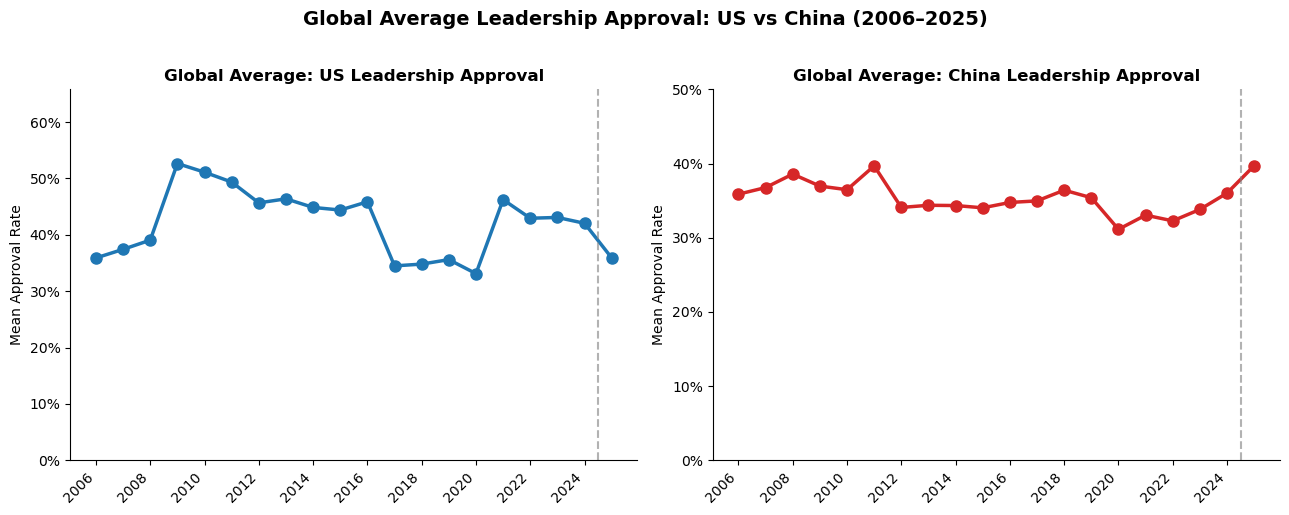


Global means:
     approve_us approve_china
year                         
2006      35.9%         35.9%
2007      37.4%         36.8%
2008      39.1%         38.6%
2009      52.6%         37.0%
2010      51.1%         36.5%
2011      49.4%         39.7%
2012      45.7%         34.1%
2013      46.4%         34.4%
2014      44.9%         34.3%
2015      44.4%         34.0%
2016      45.9%         34.8%
2017      34.5%         35.0%
2018      34.8%         36.4%
2019      35.6%         35.4%
2020      33.1%         31.1%
2021      46.2%         33.0%
2022      42.9%         32.3%
2023      43.1%         33.8%
2024      42.0%         36.0%
2025      35.9%         39.7%


In [73]:
# Global mean approval by year (across all surveyed countries)
global_means = gallup_all.groupby('year')[['approve_us', 'approve_china']].mean().reset_index()

years = sorted(global_means['year'].unique())
n_years = len(years)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, label in zip(
    axes,
    ['approve_us',    'approve_china'],
    ['#1f77b4',       '#d62728'],
    ['US Leadership', 'China Leadership']
):
    vals = global_means.set_index('year')[col]
    if n_years > 2:
        ax.plot(vals.index, vals.values, marker='o', color=color,
                linewidth=2.5, markersize=8)
        ax.axvline(2024.5, color='gray', linestyle='--', alpha=0.6, label='USAID cuts (2025)')
        ax.xaxis.set_major_locator(mtick.MultipleLocator(2))
        ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%d'))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    else:
        # Only 2 years — use a grouped bar chart for clarity
        x = np.arange(len(years))
        bars = ax.bar(x, vals.values, color=color, alpha=0.75, width=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels([str(y) for y in years], fontsize=11)
        for bar, val in zip(bars, vals.values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
        if len(vals) == 2:
            delta = vals.values[1] - vals.values[0]
            sign  = '+' if delta >= 0 else ''
            ax.text(0.97, 0.97, f'Change: {sign}{delta:.1%}',
                    transform=ax.transAxes, ha='right', va='top',
                    fontsize=10, color=color,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=color, alpha=0.8))

    ax.set_title(f'Global Average: {label} Approval', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Approval Rate', fontsize=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_ylim(0, max(global_means[col].max() * 1.25, 0.5))
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Global Average Leadership Approval: US vs China (2006–2025)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/global_approval_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGlobal means:")
print(global_means.set_index('year').map(lambda x: f'{x:.1%}'))

## 4. Build DiD Dataset

In [74]:
# ── Step 1: Harmonise Gallup country names → UN/aid naming conventions ──────
# Verified against df_clean.csv; 12 resolvable mismatches
gallup_to_aid = {
    'CONGO (KINSHASA)':                                      'DEMOCRATIC REPUBLIC OF THE CONGO',
    'CONGO BRAZZAVILLE':                                     'CONGO',
    'CZECH REPUBLIC':                                        'CZECHIA',
    'IRAN':                                                  'IRAN (ISLAMIC REPUBLIC OF)',
    'MOLDOVA, REPUBLIC OF':                                  'REPUBLIC OF MOLDOVA',
    'NETHERLANDS (KINGDOM OF THE)':                          'NETHERLANDS',
    'SOUTH KOREA':                                           'REPUBLIC OF KOREA',
    'SYRIA':                                                 'SYRIAN ARAB REPUBLIC',
    'TANZANIA':                                              'UNITED REPUBLIC OF TANZANIA',
    'TÜRKIYE':                                               'TURKEY',
    'UNITED KINGDOM OF GREAT BRITAIN AND NORTHERN IRELAND': 'UNITED KINGDOM',
    'VIETNAM':                                               'VIET NAM',
}
gallup_all['country'] = gallup_all['country'].replace(gallup_to_aid)
print(f"Applied {len(gallup_to_aid)} name corrections")

# ── Step 2: Remove non-UN-member territories ─────────────────────────────────
non_un_territories = {
    'KOSOVO',
    'HONG KONG S.A.R. OF CHINA',
    'TAIWAN (PROVINCE OF CHINA)',
    'PUERTO RICO',
    'STATE OF PALESTINE',
    'NORTHERN CYPRUS',
    'NAGORNO-KARABAKH REGION',
}
n_before = gallup_all['country'].nunique()
gallup_all = gallup_all[~gallup_all['country'].isin(non_un_territories)].copy()
n_after = gallup_all['country'].nunique()
print(f"Removed {n_before - n_after} non-UN territories → {n_after} countries, {len(gallup_all)} rows remaining")

# ── Step 3: Verify — any Gallup country now maps to >1 aid name? ─────────────
# After renaming, each Gallup country string should hit at most one aid country
aid_names = set(df_aid['country'].unique())
still_unmatched = sorted(set(gallup_all['country'].unique()) - aid_names)
print(f"\nGallup countries with no aid record ({len(still_unmatched)}) — will be set to zero:")
for c in still_unmatched:
    print(f"  {c}")

Applied 12 name corrections
Removed 7 non-UN territories → 156 countries, 2387 rows remaining

Gallup countries with no aid record (0) — will be set to zero:


In [ ]:
# ── Pre-merge diagnostics: what would inner joins drop? ──────────────────────

# Merge 1: Gallup country-years with no aid entry for that specific year
check1 = gallup_all.merge(
    df_aid[['country', 'year']], on=['country', 'year'], how='left', indicator=True
).query('_merge == "left_only"')
dropped_cy = sorted(check1['country'].unique())
print(f"Merge 1 (country+year inner): drops {len(check1)} rows across {len(dropped_cy)} countries")
for c in dropped_cy:
    yrs = sorted(check1[check1['country'] == c]['year'].tolist())
    print(f"  {c}: years {yrs}")

# Merge 2: Gallup countries not in aid_2024 (no 2024 entry)
dropped_c2 = sorted(set(gallup_all['country'].unique()) - set(aid_2024['country'].unique()))
rows_c2 = len(gallup_all[gallup_all['country'].isin(dropped_c2)])
print(f"\nMerge 2 (country inner on aid_2024): drops {rows_c2} rows — countries: {dropped_c2}")

# ── Merge 1: Gallup × annual aid/GDP ratio (inner join on country + year) ─────
print(f"\n[Before merge 1] gallup_all: {len(gallup_all):,} rows  |  {gallup_all['country'].nunique()} countries")
print(f"  df_aid (country-year ratios): {len(df_aid):,} rows  |  {df_aid['country'].nunique()} countries")

df = gallup_all.merge(
    df_aid[['country', 'year', 'aid_gdp_ratio']],
    on=['country', 'year'],
    how='inner'
)

print(f"[After  merge 1] df: {len(df):,} rows  |  {df['country'].nunique()} countries")
print(f"  aid_gdp_ratio NaNs: {df['aid_gdp_ratio'].isna().sum()}")

# ── Merge 2: attach treatment flag from 2024 (inner join on country) ──────────
print(f"\n[Before merge 2] df: {len(df):,} rows  |  {df['country'].nunique()} countries")
print(f"  aid_2024 (treatment flags): {len(aid_2024):,} rows  |  {aid_2024['country'].nunique()} countries")

df = df.merge(
    aid_2024[['country', 'treated', 'avg_aid_gdp']],
    on='country',
    how='inner'
)

print(f"[After  merge 2] df: {len(df):,} rows  |  {df['country'].nunique()} countries")
print(f"  treated NaNs: {df['treated'].isna().sum()}")

df['post'] = (df['year'] == 2025).astype(int)
df['did']  = df['post'] * df['treated']

print(f"\nFinal dataset (inner): {len(df)} country-year obs ({df['country'].nunique()} countries)")
print(f"  Treated (high-aid): {df[df['treated']==1]['country'].nunique()}")
print(f"  Control (low-aid):  {df[df['treated']==0]['country'].nunique()}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

In [77]:
# Save merged DiD dataset for analysis in 04_approval_ratings_analysis.ipynb
# Upload gallup_did_clean.csv to Google Drive and paste the file ID into notebook 04
df.to_csv('gallup_did_clean.csv', index=False)
print(f'Saved {len(df)} rows → gallup_did_clean.csv')
df

Saved 2352 rows → gallup_did_clean.csv


,country,year,approve_us,disapprove_us,net_us,approve_china,disapprove_china,net_china,aid_gdp_ratio,treated,avg_aid_gdp,post,did
0,ALBANIA,2025,0.64,0.24,0.40,0.21,0.65,-0.44,0.083221,0,0.111674,1,0
1,ALBANIA,2024,0.64,0.19,0.45,0.16,0.61,-0.45,0.111674,0,0.111674,0,0
2,ALBANIA,2023,0.63,0.16,0.47,0.16,0.55,-0.39,0.133748,0,0.111674,0,0
3,ALBANIA,2022,0.69,0.16,0.53,0.16,0.63,-0.47,0.264855,0,0.111674,0,0
4,ALBANIA,2021,0.82,0.12,0.70,0.31,0.51,-0.20,0.158690,0,0.111674,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2347,ZIMBABWE,2011,0.74,0.22,0.52,0.50,0.45,0.05,1.833551,1,0.820132,0,0
2348,ZIMBABWE,2010,0.76,0.22,0.54,0.57,0.37,0.20,1.922346,1,0.820132,0,0
2349,ZIMBABWE,2009,0.82,0.12,0.70,0.47,0.41,0.06,3.814483,1,0.820132,0,0
2350,ZIMBABWE,2008,0.74,0.22,0.52,0.57,0.36,0.21,5.356123,1,0.820132,0,0
